# Graph Models and Hypothesis Testing — SOLUTIONS (2026)

Utrecht Summer School on Network Science — Session 1


> **Maintainers:** this notebook is the *tagged master*. Cells tagged `solution` are
> removed (or replaced by their `student_source` metadata) when generating the student
> version. To regenerate the student notebook after editing this file, run:
>
> ```
> python make_student_version.py Graph_models_and_hypothesis_testing_2026_solutions.ipynb
> ```
>
> Never edit the student notebook directly — it will be overwritten.


**The question for this morning:**

> *Is what I'm seeing in my network surprising, or is it what I'd get anyway?*

Every real network "has" clustering, hubs, groups. The question is never whether these
features exist — it's whether they need an explanation beyond chance. Today you'll learn a
**ladder of null models** that answers this, and by the end of the morning you'll apply it
to a real dataset (ideally your own).

This notebook follows the **Graph Models cheat sheet** step by step — the code you run here
is the same code on the sheet, so everything you practice this morning transfers directly
to your own data this afternoon and beyond.

Some of the libraries are difficult to install on some systems, so it is best to open this
notebook in Colab
[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jgarciab/NetworkScience/blob/main/Practicals/day2a_graph_models/Graph_models_and_hypothesis_testing_2026.ipynb)

**You cannot save changes in this notebook, you need to save a copy to your Google Drive:
`File` → `Save a copy in Drive`.**


## 0 — Setup (do this first, ~5 minutes)

We use [graph-tool](https://graph-tool.skewed.de/), which is not available in the standard
Colab environment, so we install it via conda. **Run the three cells below now** — the
install takes a few minutes, and the first cell will **restart the kernel** (that is
expected, not an error).


In [1]:
!pip install -q condacolab
import condacolab
# Workaround issue with Python 3.12:
# condacolab.install()
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

✨🍰✨ Everything looks OK!


*The kernel restarts after the cell above — wait for it, then continue below.
(If a crash message appears at this stage, just run the notebook again; this is related to
the kernel switch done by condacolab.)*


In [2]:
!mamba install -q graph-tool

In [3]:
# Workaround issue with Python 3.12
!mamba install -q scipy

In [4]:
import graph_tool.all as gt
from graph_tool import topology, inference, generation, stats, correlations
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.stats import binomtest

## 1 — The null-model ladder

Two quick vignettes:

- An analyst finds that their **organisation's email network** has "unexpectedly high
  clustering" — colleagues of colleagues email each other a lot. Management concludes
  there are strong informal teams. *Is that conclusion justified?*
- In a **trade network**, one country sits in the middle of everything, and commentators
  conclude it is structurally special — a deliberate broker. *Or does it just trade a lot?*

In both cases the observation is real, but the *explanation* is only warranted if the
pattern exceeds what a suitably boring random baseline would produce. Choosing that
baseline is the whole game. We use an escalating ladder:

| Rung | Null model | What it holds fixed | Failing it tells you... |
|---|---|---|---|
| 1 | **Erdős–Rényi** | number of nodes & edges | "not maximally random" (almost everything fails this) |
| 2 | **Configuration model** | every node's degree | "there is structure beyond degree heterogeneity" |
| 3 | **DC-SBM** | degrees *and* group structure | "structure beyond blocks + degrees" → Wednesday's session |
| — | **BESTest** | a node attribute you have | "this attribute is (not) associated with the structure" |

**Each rung rules out a more sophisticated "boring" explanation.** Don't skip to the most
complex model — the point of the ladder is knowing *which* baseline your result actually
needs to beat.

The decision tree (also on your cheat sheet):

```
Do you have a specific count/degree you're questioning?
 └─ yes → Step 1 (ER / binomial test)

Is a global property (clustering, assortativity, degree distribution shape)
surprising relative to a random graph?
 └─ yes → Step 2 (configuration model null test)

Do you suspect group/block structure (even without knowing the groups)?
 └─ yes → Step 3 (DC-SBM) → Wednesday + Community Detection cheat sheet

Do you have a labelled attribute you want to test for relevance?
 └─ yes → BESTest
```

The rest of this notebook climbs this ladder on real data. First, a short gallery of the
network models themselves, so the words "random graph" and "configuration model" mean
something concrete.


## 2 — Baseline vocabulary: a fast gallery of network models

**This section is run-and-discuss, not typing.** All the code is complete — execute each
cell, look at the picture or plot, and answer the discussion prompt with your neighbour.
The graph-tool documentation for these models is
[here](https://graph-tool.skewed.de/static/doc/generation.html).

Real-world networks tend to exhibit three properties, and each model below captures some
but not all of them:

1. High clustering (closed triangles)
2. Short path lengths
3. Heavy-tailed degree distributions


### 2.1 Regular graphs and lattices

All nodes have (roughly) the same degree, arranged in a regular pattern.


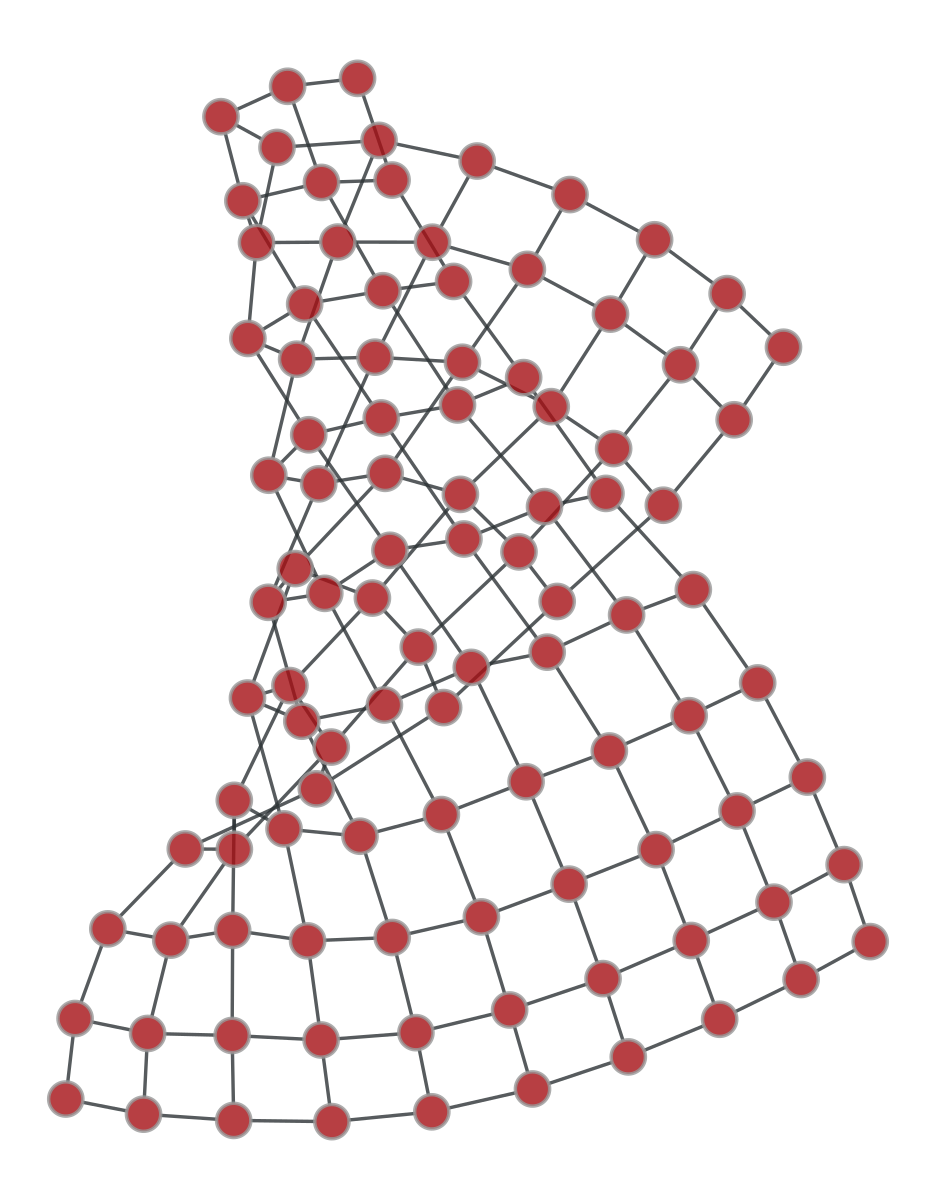

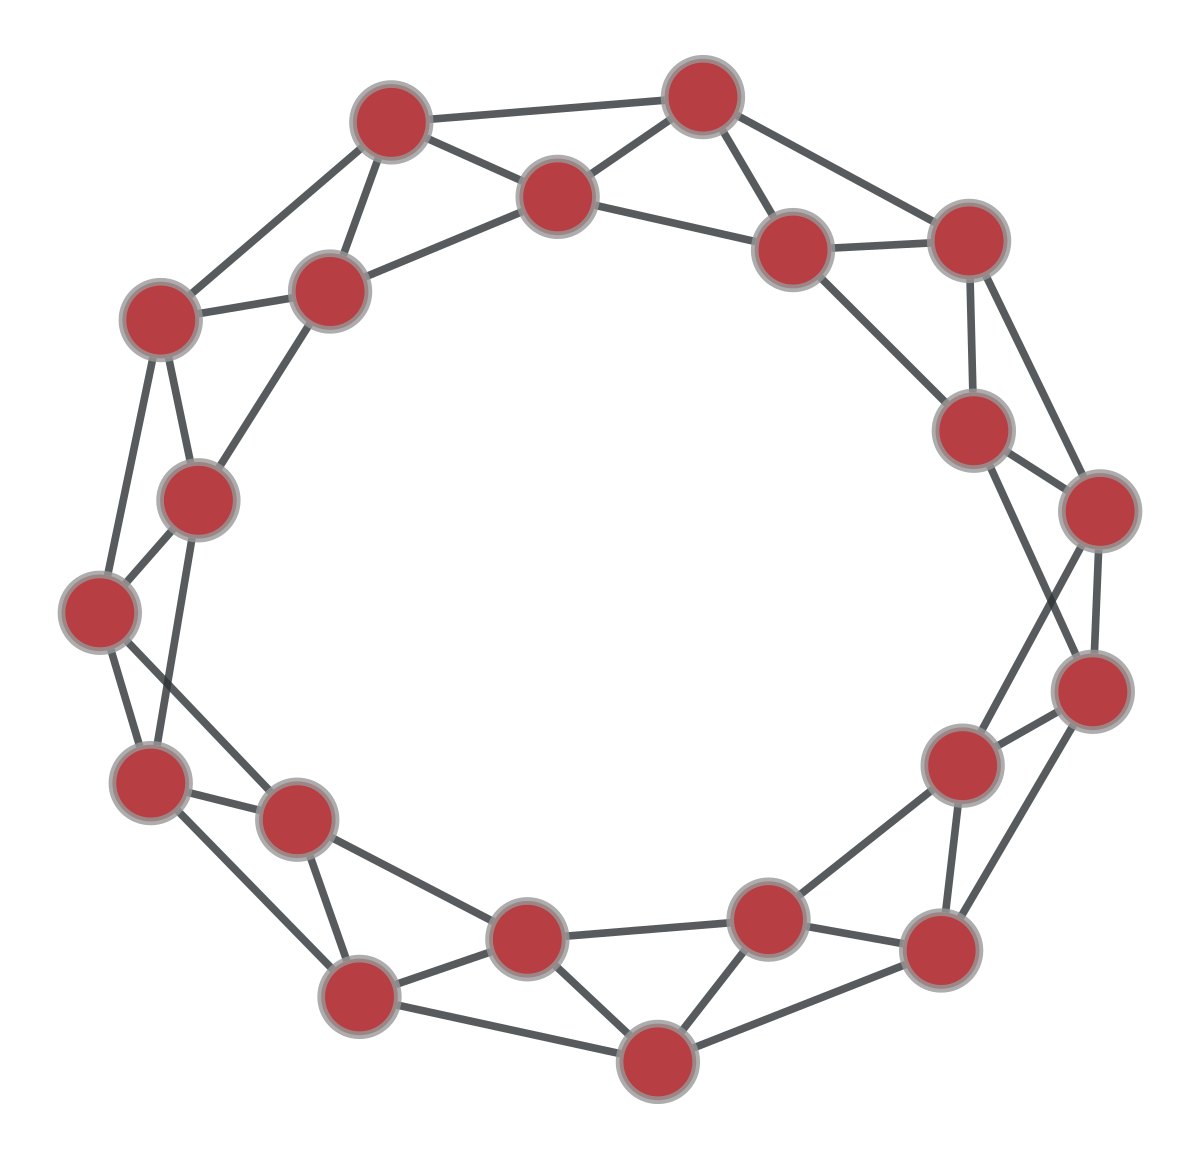

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x79dbc09dfe00, at 0x79db781b8aa0>

In [7]:
# generate square lattice
g = gt.lattice([10, 10])
pos = gt.sfdp_layout(g, cooling_step=0.95, epsilon=1e-2)
gt.graph_draw(g, pos=pos)

# generate ring lattice (each node connected to its 2 nearest neighbours on each side)
g = gt.circular_graph(20, 2)
pos = gt.sfdp_layout(g, cooling_step=0.95)
gt.graph_draw(g, pos=pos)

In [8]:
print('Number of nodes', g.num_vertices())
print('Number of edges', g.num_edges())
print('Clustering coefficient', gt.local_clustering(g).fa.mean())
# Calculating the average path length exactly is expensive for large networks,
# so we use the pseudo diameter as an approximation
print('Average path length', gt.pseudo_diameter(g)[0])

Number of nodes 20
Number of edges 40
Clustering coefficient 0.5
Average path length 5.0


**Discuss:** lattices have high clustering — which of the three real-world properties do
they clearly *fail* on? (Look at the path length relative to the number of nodes.)


*Answer: path lengths. In a ring lattice distances grow linearly with the number of
nodes — there are no shortcuts, so a 1000-node ring has typical distances in the hundreds,
whereas real networks of that size have typical distances below 10. Degree distributions
are also unrealistically homogeneous (every node identical).*


### 2.2 Random (Erdős–Rényi) graphs

In the Erdős–Rényi model every pair of nodes has the same probability of being connected.
This is rung 1 of the ladder.


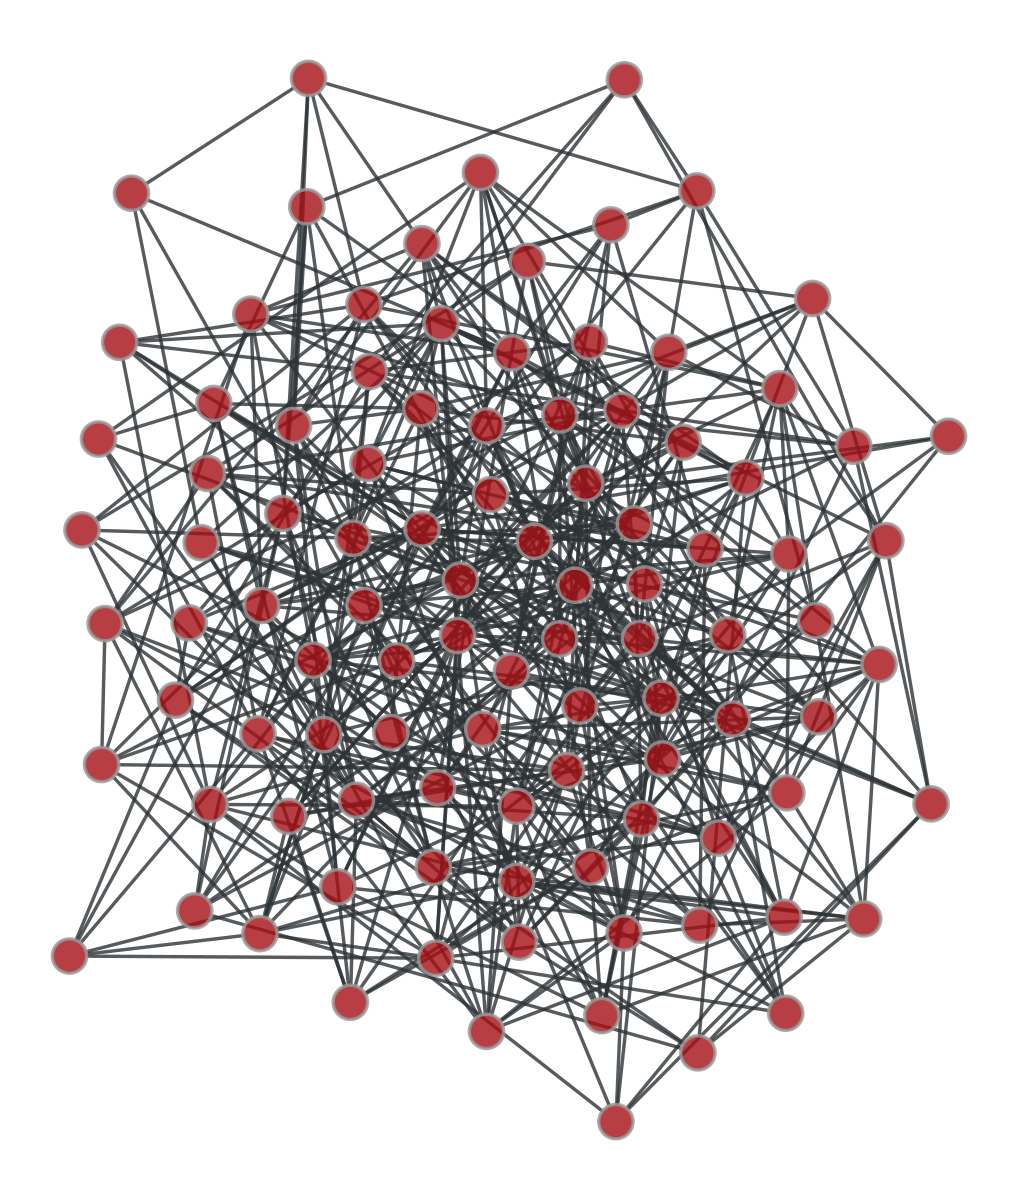

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x79db78278d10, at 0x79db782790d0>

In [9]:
g = gt.random_graph(100, lambda: np.random.poisson(10), directed=False)
gt.graph_draw(g)

Number of nodes 100
Number of edges 510
Clustering coefficient 0.1009870537958773
Average path length 3.0


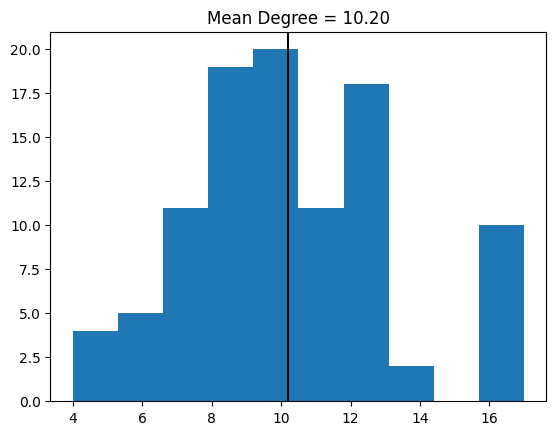

In [10]:
print('Number of nodes', g.num_vertices())
print('Number of edges', g.num_edges())
print('Clustering coefficient', gt.local_clustering(g).fa.mean())
print('Average path length', gt.pseudo_diameter(g)[0])

# degree distribution
degree_sequence = g.get_total_degrees(list(g.vertices()))
_ = plt.hist(degree_sequence, bins=10)
_ = plt.axvline(np.mean(degree_sequence), color='black')
_ = plt.title('Mean Degree = {:.2f}'.format(np.mean(degree_sequence)))

**Discuss:** compared to the lattice — what happened to clustering, and what happened
to path length? And how would you describe the *shape* of the degree distribution
(heavy-tailed or concentrated around the mean)?


*Answer: clustering collapses to roughly $c/n$ (here ~0.1, and it shrinks further as
the network grows), while path lengths become short ($\sim \log n$). The degree
distribution is Poisson — concentrated tightly around the mean, no hubs. So ER gets
property 2 right and properties 1 and 3 wrong: it is the "maximally boring" baseline.*


### 2.3 Small-world networks: interpolating between the two

Watts–Strogatz-style small-world networks randomise a fraction $p$ of the links in a
regular ring, keeping the rest of the regular structure.

![image.png](https://drive.google.com/uc?id=1P8ewNjJuGlnIvZp1RKF2WCQwAFaZ8AL5)

The sweep below regenerates the network for 14 values of $p$ and tracks clustering and
diameter relative to the unrewired ring ($p=0$).


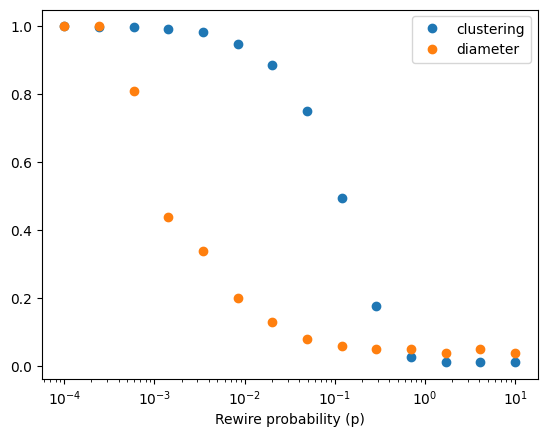

In [11]:
n_networks = 14
rewire_probs = np.logspace(-4, 1, n_networks)
n_nodes = 1000
n_edges = 5000
g = gt.circular_graph(n_nodes, n_edges / n_nodes)

C0 = gt.global_clustering(g)[0]
L0 = gt.pseudo_diameter(g)[0]

clusts = np.empty(n_networks)
lengths = np.empty(n_networks)

for i in range(n_networks):
    g = gt.circular_graph(n_nodes, n_edges / n_nodes)
    p = rewire_probs[i]
    generation.random_rewire(g, n_iter=int(np.round(p * n_edges)), edge_sweep=False)
    clusts[i] = gt.global_clustering(g)[0] / C0
    lengths[i] = gt.pseudo_diameter(g)[0] / L0

plt.semilogx(rewire_probs, clusts, 'o', label='clustering')
plt.semilogx(rewire_probs, lengths, 'o', label='diameter')
plt.legend()
_ = plt.xlabel('Rewire probability (p)')

**Discuss:** what range of $p$ produces "realistic" networks — i.e. keeps high
clustering *and* short paths at the same time?


*Answer: the intermediate window, roughly $p \approx 0.01$–$0.1$. Diameter collapses
after only a handful of shortcuts (it drops at much smaller $p$ than clustering does), while
clustering survives until a much larger fraction of edges is rewired — so there is a wide
band where both look "real". This is the small-world regime.*


### 2.4 The Price model (preferential attachment)

The models so far all create relatively homogeneous degree distributions. The Price model
(Barabási–Albert, if undirected) grows a network where new nodes attach preferentially to
already-popular nodes — producing hubs and a heavy tail.


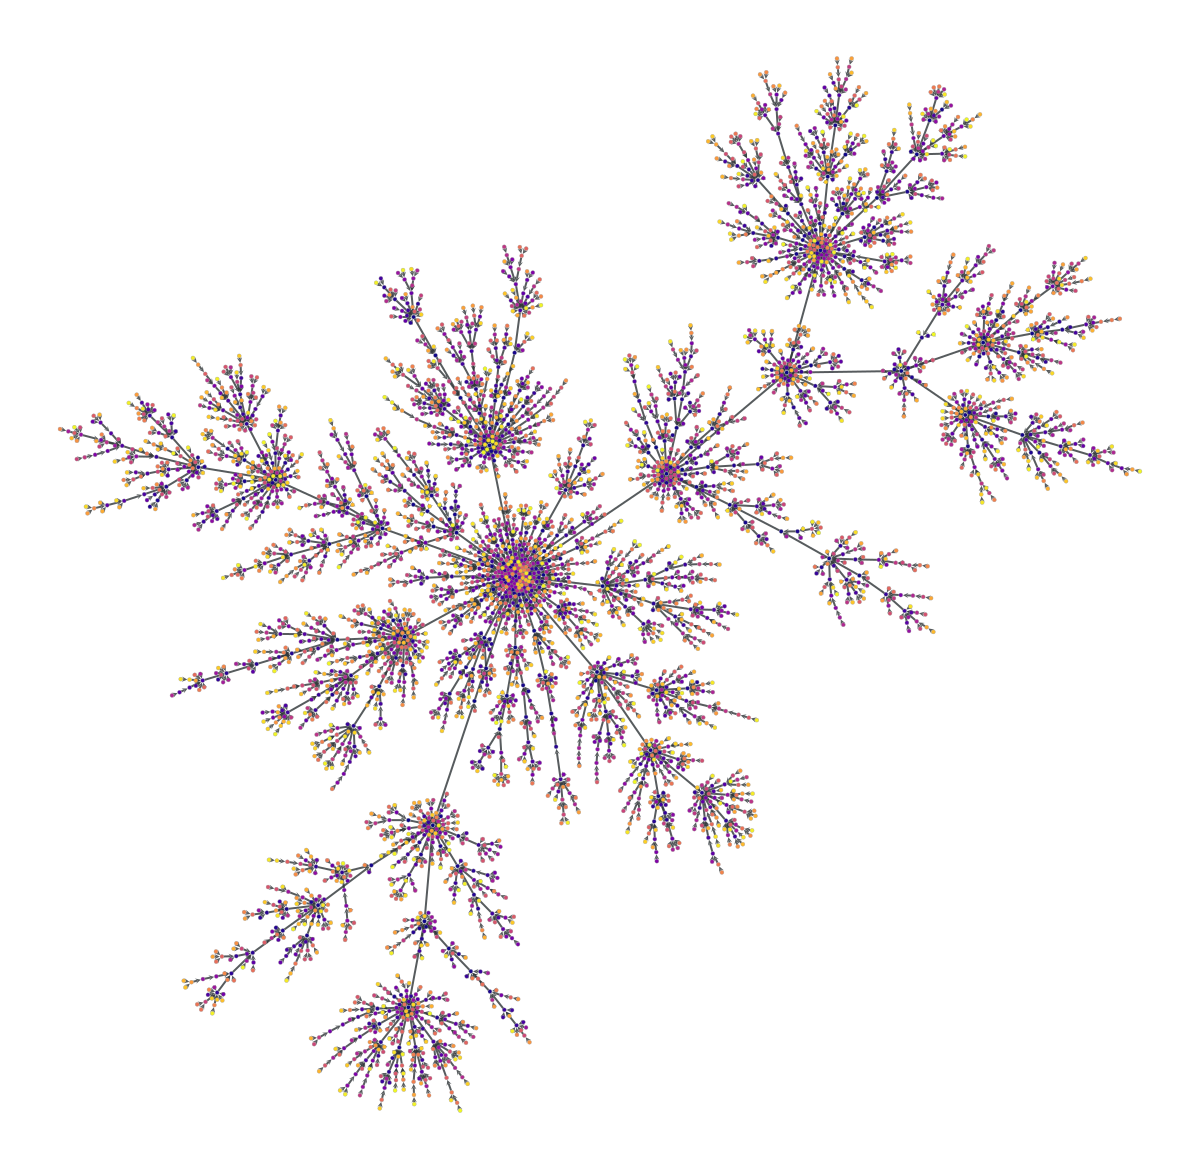

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x79db760ea450, at 0x79db793c35f0>

In [12]:
g = gt.price_network(5000)

gt.graph_draw(g, pos=gt.sfdp_layout(g, cooling_step=0.99),
              vertex_fill_color=g.vertex_index, vertex_size=2,
              vcmap=mpl.cm.plasma,
              edge_pen_width=1)

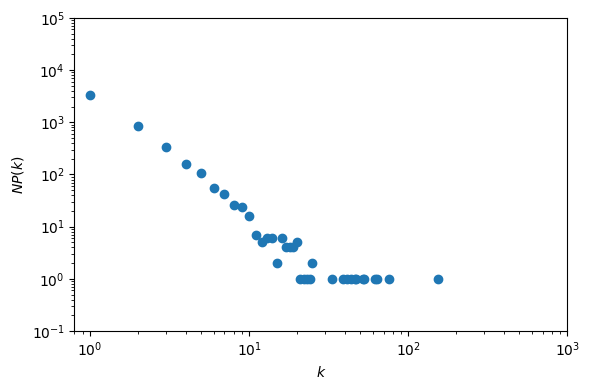

In [13]:
# degree distribution on log-log axes
in_hist = gt.vertex_hist(g, "total")

plt.figure(figsize=(6, 4))
plt.errorbar(in_hist[1][:-1], in_hist[0], fmt="o", yerr=0)
plt.gca().set_yscale("log")
plt.gca().set_xscale("log")
plt.gca().set_ylim(1e-1, 1e5)
plt.gca().set_xlim(0.8, 1e3)
plt.xlabel("$k$")
plt.ylabel("$NP(k)$")
plt.tight_layout()

The colours in the drawing indicate the order in which nodes were added — the oldest
nodes became the hubs. The straight line on log-log axes is the signature of a heavy tail.

**Why this matters for the ladder:** heavy-tailed degrees *on their own* can produce
apparent clustering, apparent communities, apparent core-periphery structure. So "my
network has hubs" is precisely the boring explanation that rung 2 is designed to control
for.


### 2.5 The configuration model: our rung-2 machine

The configuration model keeps every node's degree **exactly as observed** but rewires who
connects to whom, uniformly at random. One line of graph-tool turns any network into a
sample from its own configuration model:


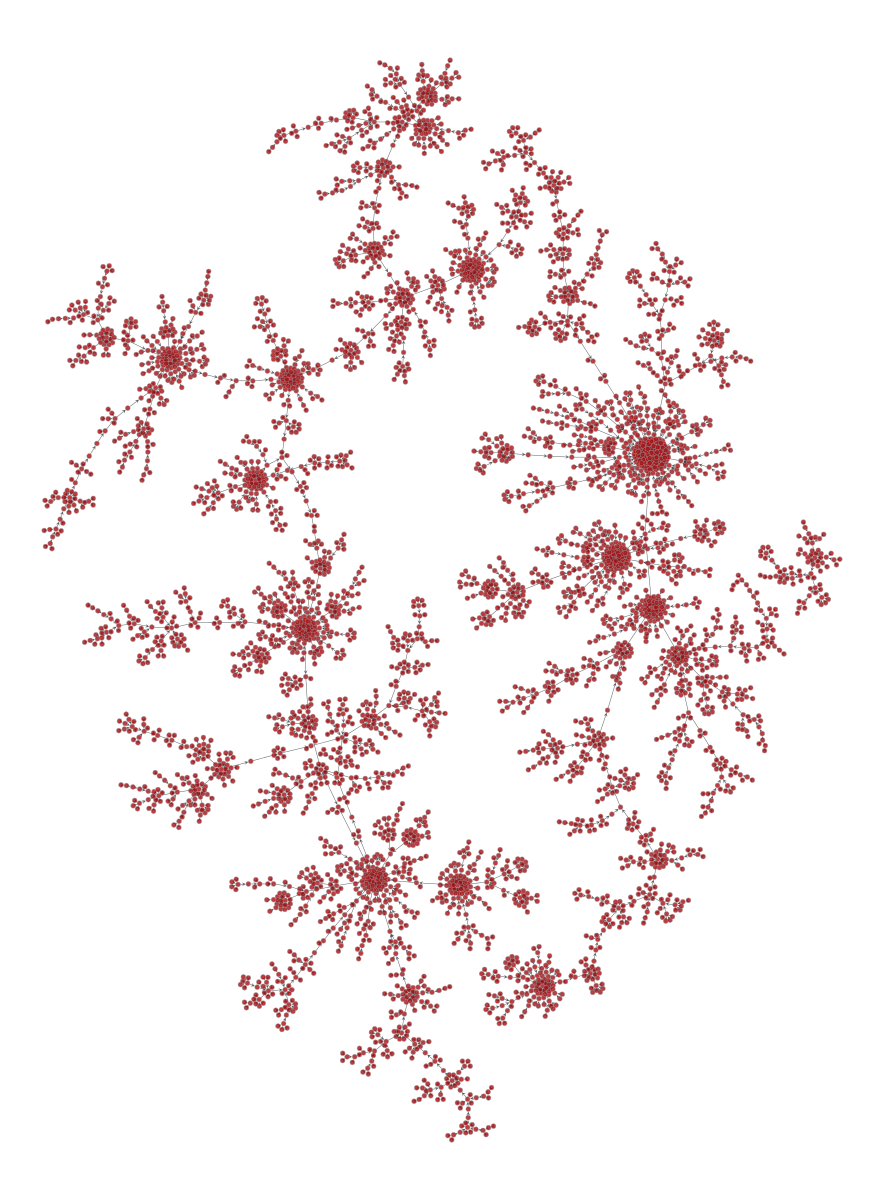

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x79db760ea450, at 0x79db6d5c7bf0>

In [14]:
generation.random_rewire(g, model='configuration')  # degrees preserved, everything else scrambled
gt.graph_draw(g)

Same hubs, same degree histogram — but any *additional* structure (clustering,
communities, attribute alignment) has been destroyed. Repeating this many times gives a
null *distribution* for any statistic you care about. That recipe is the workhorse of the
rest of the morning, and of Wednesday too.


## 3 — Rung 1 in practice: "is this degree surprising?"

Time to climb the ladder on real data. Under ER with $n$ nodes and connection probability
$p$, a node's degree follows a binomial distribution — so "is this node's degree
surprisingly high?" is a textbook binomial test.

First, calibrate your intuition on a network where we *know* the answer, because we
generated it: an ER graph with 1000 nodes and mean degree 10.


In [15]:
g = gt.random_graph(1000, lambda: np.random.poisson(10), directed=False)
degree_sequence = g.get_total_degrees(list(g.vertices()))

n = 1000    # number of nodes
c = 10      # mean degree
p = c / (n - 1)   # probability of a connection

# probability that a single node has at least 15 connections, by chance
test = binomtest(15, n - 1, p, alternative='greater')
test.pvalue

np.float64(0.0824112676837848)

**Exercise 1a.** How many nodes in this network actually have at least 15 connections?
How many would you *expect* to have at least 15, given the p-value above?


In [16]:
## SOLUTION

print(f'The network has {sum(degree_sequence >= 15)} nodes with at least 15 connections.')
print(f'In an ER network with {n} nodes and mean degree {c} we would expect '
      f'{n * test.pvalue:.1f} such nodes.')

# Take-away: a degree of 15 is NOT surprising here, even though it is 50% above the
# mean — with 1000 nodes, dozens of them will exceed it by chance alone. Always ask
# "how many chances did randomness get?" before calling something an outlier.

The network has 93 nodes with at least 15 connections.
In an ER network with 1000 nodes and mean degree 10 we would expect 82.4 such nodes.


### A real network: face-to-face contacts in a high school

The network below records face-to-face proximity interactions between high-school students
(measured with wearable sensors, [SocioPatterns](http://www.sociopatterns.org/), Marseille
2013). We take the interactions from the first hour of the school day, and collapse
repeated contacts between the same pair into a single edge.


In [17]:
!wget https://networks.skewed.de/net/sp_high_school/files/proximity.gt.zst
g_proximity = gt.load_graph("proximity.gt.zst")

# interactions in the first hour of the dataset
g_prox_hour1 = gt.Graph(
    gt.GraphView(g_proximity, efilt=lambda e: g_proximity.ep.time[e] <= 1385982020 + 3600),
    prune=True)
# collapse repeated contacts between the same pair into one edge
gt.remove_parallel_edges(g_prox_hour1)

print('Nodes:', g_prox_hour1.num_vertices(), ' Edges:', g_prox_hour1.num_edges())

--2026-07-13 19:47:23--  https://networks.skewed.de/net/sp_high_school/files/proximity.gt.zst
Resolving networks.skewed.de (networks.skewed.de)... 49.12.93.194
Connecting to networks.skewed.de (networks.skewed.de)|49.12.93.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 205530 (201K) [application/zstd]
Saving to: ‘proximity.gt.zst’

proximity.gt.zst    100%[===================>] 200.71K   453KB/s    in 0.4s    

2026-07-13 19:47:24 (453 KB/s) - ‘proximity.gt.zst’ saved [205530/205530]

Nodes: 329  Edges: 823


**Exercise 1b.** Plot the degree distribution of the hour-1 contact network. Then pick
the highest-degree node and test whether its degree is surprising under an ER null with the
same number of nodes and edges. (Cheat sheet, Step 1.)

*State your assumptions:* this is where real data gets messy. Some students have degree 0
in the first hour — should they count towards $n$? There is no single right answer, but
your test is only as meaningful as the null you chose.


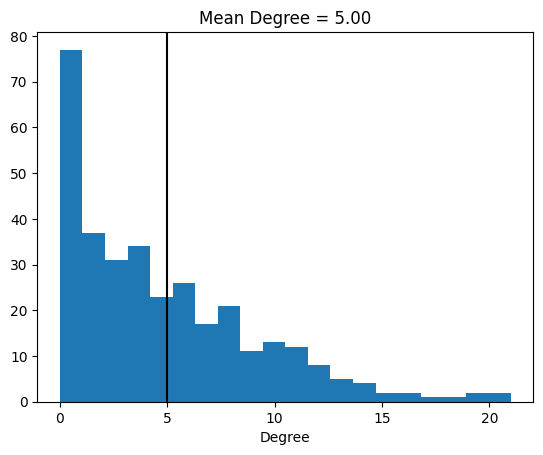

Highest degree: 21
P(a given node has degree >= 21 under ER) = 5.58e-08
Expected number of such nodes among 329: 0.0000


In [18]:
## SOLUTION

degree_sequence = g_prox_hour1.get_total_degrees(list(g_prox_hour1.vertices()))
_ = plt.hist(degree_sequence, bins=20)
_ = plt.axvline(np.mean(degree_sequence), color='black')
_ = plt.title('Mean Degree = {:.2f}'.format(np.mean(degree_sequence)))
plt.xlabel('Degree')
plt.show()

n = g_prox_hour1.num_vertices()
m = g_prox_hour1.num_edges()
c = 2 * m / n                    # mean degree (undirected)
p = c / (n - 1)

k_max = int(degree_sequence.max())
test = binomtest(k_max, n - 1, p, alternative='greater')
print(f'Highest degree: {k_max}')
print(f'P(a given node has degree >= {k_max} under ER) = {test.pvalue:.2e}')
print(f'Expected number of such nodes among {n}: {n * test.pvalue:.4f}')

# Even after multiplying by n (i.e. giving randomness n chances), the expected count is
# far below 1 — this degree is not explained by uniformly random mixing.
#
# Assumption check: n includes students with zero hour-1 contacts. Excluding them
# raises the mean degree of the null and makes the hub LESS surprising — try it. The
# conclusion here survives either way, but on marginal results this choice can flip
# the answer, which is exactly why you must state it.

**But hold on.** All we have shown is that this network is not *maximally* random.
ER shares edges out with no memory of node degrees, so almost any real network fails
against it — a rejection tells you almost nothing about *why*. This is the limitation of
rung 1, and the reason the ladder continues.


## 4 — Rung 2 in practice: the configuration-model null test

**The question:** once we fix each student's *number* of contacts, is there still extra
structure — for example clustering — that degree heterogeneity alone wouldn't produce?

**The recipe**:

1. compute your statistic on the observed network;
2. rewire with `model='configuration'` (degrees preserved), recompute the statistic;
3. repeat many times to build a null distribution;
4. the p-value is the fraction of null samples at least as extreme as the observation.

**Exercise 2.** Run this test for the mean local clustering coefficient of the hour-1
contact network. Plot the null distribution as a histogram with the observed value as a
vertical line, and compute the empirical p-value.


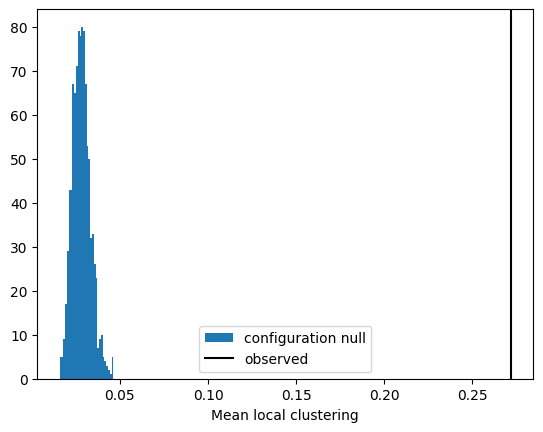

Observed clustering: 0.272
Null mean: 0.028  (p-value: 0.000)


In [19]:
## SOLUTION

observed = gt.local_clustering(g_prox_hour1).fa.mean()

g_rand = g_prox_hour1.copy()
n_samples = 1000        # use 1000 for a final analysis; 200 keeps the class moving
stat_values = np.empty(n_samples)

for i in range(n_samples):
    generation.random_rewire(g_rand, model='configuration')   # preserves degrees
    stat_values[i] = gt.local_clustering(g_rand).fa.mean()

pvalue = np.mean(stat_values >= observed)

plt.hist(stat_values, bins=30, label='configuration null')
plt.axvline(observed, color='black', label='observed')
plt.legend()
plt.xlabel('Mean local clustering')
plt.show()
print(f'Observed clustering: {observed:.3f}')
print(f'Null mean: {stat_values.mean():.3f}  (p-value: {pvalue:.3f})')

*Interpretation: the observed clustering sits far to the right of the entire null
distribution (empirical p-value 0, i.e. below $1/n_{samples}$) — the students' contacts
close far more triangles than their contact counts alone can explain. Unlike the ER
rejection, this is informative: something beyond degree — friendship groups, classes,
shared rooms — is shaping who meets whom. Which "something"? That's rung 3, and Wednesday.*

*One subtlety worth saying out loud: each `random_rewire` call continues scrambling the
same graph copy, so consecutive samples are steps of a randomisation chain rather than
independent draws — fine for this purpose, and the same pattern you'll use Wednesday.*


**Exercise 2b — swap the statistic.** The loop above is a *general* recipe: nothing
about it is specific to clustering. Rerun the test with degree assortativity
(`correlations.assortativity(g, 'total')[0]`) as the statistic. Do students with many
contacts preferentially meet other students with many contacts, beyond what their degrees
require?


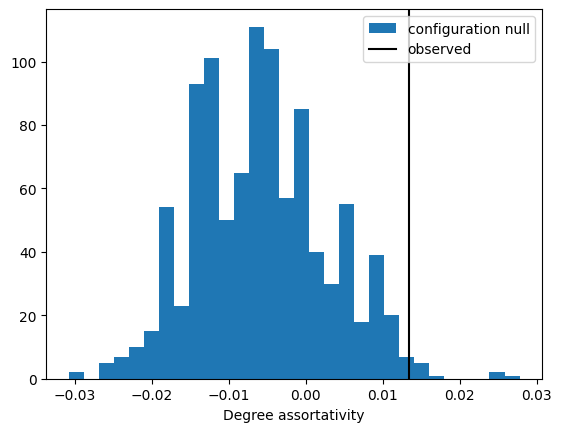

Observed assortativity: 0.013  (p-value: 0.023)


In [20]:
## SOLUTION

observed = correlations.assortativity(g_prox_hour1, 'total')[0]

g_rand = g_prox_hour1.copy()
n_samples = 1000
stat_values = np.empty(n_samples)

for i in range(n_samples):
    generation.random_rewire(g_rand, model='configuration')
    stat_values[i] = correlations.assortativity(g_rand, 'total')[0]

# two-sided version: surprise in either direction counts
pvalue = np.mean(np.abs(stat_values - stat_values.mean())
                 >= np.abs(observed - stat_values.mean()))

plt.hist(stat_values, bins=30, label='configuration null')
plt.axvline(observed, color='black', label='observed')
plt.legend()
plt.xlabel('Degree assortativity')
plt.show()
print(f'Observed assortativity: {observed:.3f}  (p-value: {pvalue:.3f})')

# Note the change to a two-sided test: for assortativity, both "more assortative than
# chance" and "more DISassortative than chance" would be interesting. Choosing the
# alternative hypothesis is part of choosing the test.

## 5 — A five-minute aside: the friendship paradox

"Your friends have more friends than you do" — on average, in almost any network, because
high-degree nodes appear in many people's friend lists. It is a property of sampling, not
of you.

**Exercise 3.** Test whether the friendship paradox holds in the (full, all-days) proximity
network: for what proportion of students is their own degree higher than the average degree
of their contacts?


In [21]:
# load the full proximity network and collapse repeated contacts into single edges
g_proximity_simple = g_proximity.copy()
gt.remove_parallel_edges(g_proximity_simple)
print(g_proximity_simple.num_vertices(), 'nodes,', g_proximity_simple.num_edges(), 'edges')

329 nodes, 5818 edges


In [22]:
## SOLUTION

# adjacency matrix and degree vector
A = gt.adjacency(g_proximity_simple)
k = np.asarray(A.sum(axis=1)).ravel()
# mean degree of each node's neighbours
friend_degrees = np.asarray(A.dot(k)).ravel() / k
# proportion of nodes with more contacts than their average contact
popular_nodes = np.sum(k > friend_degrees) / len(k)
print('Proportion of students with more contacts than their average contact:',
      f'{popular_nodes:.2f}')

Proportion of students with more contacts than their average contact: 0.33


/tmp/ipykernel_2537/2701819252.py:7: RuntimeWarning: invalid value encountered in divide
  friend_degrees = np.asarray(A.dot(k)).ravel() / k


## 6 — The BESTest: "does this thing I know about my nodes actually matter?"

This is the most directly reusable technique of the morning. Almost everyone's own network
comes with node labels — department, team, country, category, school class. The obvious
question is whether that label is actually associated with the network structure, or
whether the alignment you think you see in the layout is in your head.

**The idea** ([Peel, Larremore & Clauset, *Science Advances* 2017](https://doi.org/10.1126/sciadv.1602548)):
treat the attribute as a *partition* of the nodes and measure how well it compresses the
network, using the entropy of a stochastic block model fixed to that partition. Lower
entropy = the partition explains the edge pattern better. Then compare against the entropy
of *random* partitions with the same number of groups: if the attribute does no better than
random labels, it is not associated with the structure.

This is the same null-distribution logic as Section 4 — we've just swapped "rewire the
network" for "shuffle the labels", and the statistic is now model-based.


In [51]:
def random_entropy(g, n_groups):
    n = g.num_vertices()
    group_sizes = np.array(n_groups)                       # array of group sizes, e.g. np.bincount(b_observed.a)
    b = np.random.choice(len(group_sizes), size=n, p=group_sizes / group_sizes.sum())
    vprop_b = g.new_vertex_property("int64_t")
    for i in range(n):
        vprop_b[g.vertex(i)] = b[i]
    state = gt.BlockState(g, b=vprop_b)
    return state.entropy()

### The Lazega lawyers network

71 partners and associates of a US corporate law firm, with several relationship layers
(co-work, advice, friendship) and rich node attributes: which of the three **offices** they
sit in, their **practice** (litigation vs corporate), **status** (partner vs associate),
**law school**, and **gender**. We start with the co-work layer.


In [24]:
!wget 'https://github.com/jgarciab/NetworkScience/raw/main/Data/law_firm.gt.zst'
g = gt.load_graph('law_firm.gt.zst')

# layer 1 = co-work
u = gt.GraphView(g, efilt=lambda e: g.ep.layer[e] == 1)
g1 = gt.Graph(u, prune=True)
print('Available node attributes:', list(g1.vp.keys()))

--2026-07-13 19:47:33--  https://github.com/jgarciab/NetworkScience/raw/main/Data/law_firm.gt.zst
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jgarciab/NetworkScience/main/Data/law_firm.gt.zst [following]
--2026-07-13 19:47:33--  https://raw.githubusercontent.com/jgarciab/NetworkScience/main/Data/law_firm.gt.zst
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4352 (4.2K) [application/octet-stream]
Saving to: ‘law_firm.gt.zst’

law_firm.gt.zst     100%[===================>]   4.25K  --.-KB/s    in 0s      

2026-07-13 19:47:33 (41.7 MB/s) - ‘law_firm.gt.zst’ saved [4352/4352]

Available node a

**Guided run — does the office explain who works with whom?** Run the three cells
below together with the room.


In [48]:
attr_name = 'nodeOffice'
# Create a new vertex property map of type 'long' from the existing 'nodeOffice' property
# to ensure compatibility with gt.BlockState.
b = g1.new_vertex_property("int64_t", vals=g1.vp[attr_name])
state = gt.BlockState(g1, b=b)
test_value = state.entropy()
print('observed test statistic (entropy):', test_value)

observed test statistic (entropy): 2271.006428274438 3


In [52]:
n_samples = 1000
n_groups = np.bincount(g1.vp[attr_name].a.astype(int))
null_entropy = np.empty(n_samples)
for i in range(n_samples):
    null_entropy[i] = random_entropy(g1, n_groups)

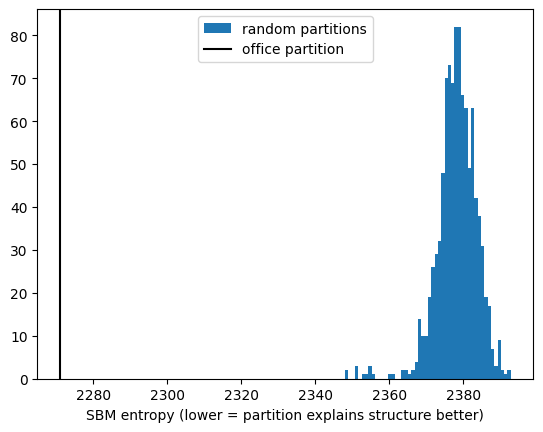

p-value: 0.0000


In [53]:
plt.hist(null_entropy, bins=50, label='random partitions')
plt.axvline(test_value, color='black', label='office partition')
plt.legend()
plt.xlabel('SBM entropy (lower = partition explains structure better)')
plt.show()

pvalue = np.mean(null_entropy <= test_value)
print(f'p-value: {pvalue:.4f}')

**Discuss before scrolling on:** the observed entropy is *lower* than the null — what
does that mean in plain language? And why is the p-value computed with `<=` here, when in
Section 4 we used `>=`?


*Answer: the office partition compresses the co-work network far better than random
3-group labellings ever do — who you work with is strongly associated with where you sit.
We use `<=` because for entropy, LOWER is better ("more explanatory"): the extreme tail of
interest is the left one. Always know which direction of your statistic means "surprising".*


**Exercise 4 — which attribute explains the most?** Repeat the test for the other
categorical attributes: `nodePractice`, `nodeStatus`, `nodeLawSchool`, `nodeGender`.
Rank the attributes by how strongly they are associated with the co-work structure.

One catch: the raw entropies are **not comparable across attributes** — partitions with
different numbers of groups live on different scales. Compare each attribute against *its
own* null (e.g. via the p-value, or a z-score
$z = (H_{obs} - \bar H_{null}) / \sigma_{null}$ — more negative = more explanatory).


In [57]:
## SOLUTION

attrs = ['nodeOffice', 'nodePractice', 'nodeStatus', 'nodeLawSchool', 'nodeGender']
n_samples = 1000

print(f"{'attribute':<15s} {'groups':>6s} {'entropy':>10s} {'p-value':>8s} {'z-score':>8s}")
for attr_name in attrs:
    b = g1.new_vertex_property("int64_t", vals=g1.vp[attr_name])
    state = gt.BlockState(g1, b=b)
    obs = state.entropy()
    n_groups = np.bincount(g1.vp[attr_name].a.astype(int))
    null = np.array([random_entropy(g1, n_groups) for _ in range(n_samples)])
    pvalue = np.mean(null <= obs)
    z = (obs - null.mean()) / null.std()
    print(f"{attr_name:<15s} {len(n_groups):>6d} {obs:>10.1f} {pvalue:>8.3f} {z:>+8.1f}")

# Typical result: office and practice are strongly associated with co-work (large
# negative z, p ~ 0); status somewhat; law school and gender little or not at all.
# The z-scores let you RANK them even though their raw entropies aren't comparable.

attribute       groups    entropy  p-value  z-score
nodeOffice           4     2271.0    0.000    -17.5
nodePractice         3     2265.3    0.000    -29.2
nodeStatus           3     2295.7    0.000    -21.1
nodeLawSchool        4     2389.7    0.218     -0.8
nodeGender           3     2345.4    0.067     -1.5


**Exercise 5 — BESTest on the contact network.** The proximity network comes with node
attributes too (print `list(g_proximity_simple.vp.keys())` to see them). Test whether the
school **class** a student belongs to is associated with their face-to-face contacts. Given
Exercise 2, are you expecting a significant result?


Available attributes: ['id', 'class', 'gender', '_pos']


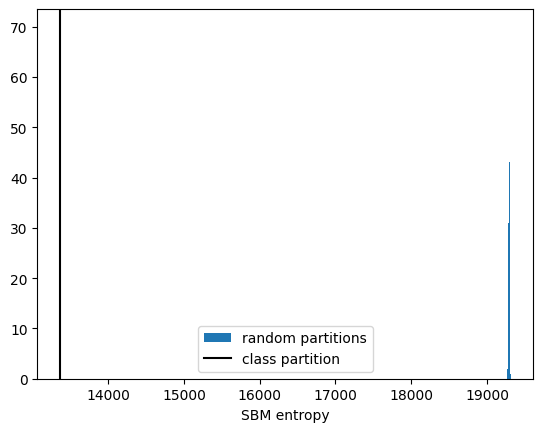

p-value: 0.0000


In [64]:
## SOLUTION

print('Available attributes:', list(g_proximity_simple.vp.keys()))

attr_name = 'class'
# class labels are strings -> map them to integers for BlockState
labels = [g_proximity_simple.vp[attr_name][v] for v in g_proximity_simple.vertices()]
cats = sorted(set(labels))
mapping = {c: i for i, c in enumerate(cats)}
b = g_proximity_simple.new_vertex_property('int64_t')
for v in g_proximity_simple.vertices():
    b[v] = mapping[g_proximity_simple.vp[attr_name][v]]

state = gt.BlockState(g_proximity_simple, b=b)
test_value = state.entropy()

n_samples = 1000
n_groups = np.bincount(b)
null_entropy = np.array([random_entropy(g_proximity_simple, n_groups)
                         for _ in range(n_samples)])

plt.hist(null_entropy, bins=50, label='random partitions')
plt.axvline(test_value, color='black', label='class partition')
plt.legend()
plt.xlabel('SBM entropy')
plt.show()
print(f'p-value: {np.mean(null_entropy <= test_value):.4f}')

# Unsurprising but now QUANTIFIED: the class partition explains contacts vastly better
# than chance — school classes are exactly the "something beyond degree" that Exercise 2
# detected but could not name. This is the bridge to Wednesday: what if you DON'T have
# the class labels, and want to discover the groups from the network alone?

**Keep the BESTest in your pocket.** It comes back on Wednesday with a second job:
after you *discover* communities with the SBM, you can validate them against an attribute
using exactly this test. One tool, two sessions.


## 7 — Practical time: the full ladder on a real, messy network

Now you run the whole argument end to end, with the cheat sheet as your guide and
instructors circulating. **Work in pairs. Pick ONE of the three datasets below** — each
comes with a naive claim of the kind you'll meet in the wild. Your job is to decide, rung
by rung, how much of the claim survives.

The pipeline (= the cheat sheet, top to bottom):

- **Step 0** — describe: nodes, edges, clustering, path length, degree distribution.
- **Step 1** — ER/binomial: is the most extreme degree surprising?
- **Step 2** — configuration null: does clustering (or another statistic) survive?
- **Step 3** — DC-SBM: `gt.minimize_blockmodel_dl(g, state_args={'deg_corr': True})` —
  is there block structure beyond degrees? (A preview of Wednesday: just fit it and look
  at the number of groups it finds.)
- **BESTest** — if the dataset has a node attribute, test whether it matters.

**As soon as your own data is ready, switch to it** — same cheat sheet, and the loader you
smoke-tested in Section 0b (full scaffold in the BYOD starter notebook). There is no
"own-data moment"; just move when you're ready.

One helper first — real datasets often store attributes as strings, and `BlockState` needs
integers:


In [70]:
def categorical_to_int(g, prop_name):
    """Map a categorical vertex property to an int vertex property (0..K-1).
    Returns the int property and the {category: int} mapping."""
    labels = [g.vp[prop_name][v] for v in g.vertices()]
    cats = sorted(set(labels))
    mapping = {c: i for i, c in enumerate(cats)}
    b = g.new_vertex_property('int64_t') # Changed 'int' to 'int64_t'
    for v in g.vertices():
        b[v] = mapping[g.vp[prop_name][v]]
    return b, mapping

### Dataset A — Computer science faculty hiring

*Who hires whose PhD graduates as faculty* among 206 US/Canadian computer science
departments ([Clauset, Arbesman & Larremore, 2015](https://doi.org/10.1126/sciadv.1400005)).
A directed edge $i \to j$ means a PhD from $i$ became faculty at $j$. Node attributes
include a prestige score (`pi`) and geographic `Region`.

**The naive claim:** *"A handful of elite departments are structurally special hubs of the
hiring system."* Special compared to what — is it more than a heavy-tailed degree
distribution? And is geography (`Region`) associated with who hires from whom?


In [66]:
g_fh = gt.collection.ns["faculty_hiring/computer_science"]
print(g_fh)
print('Node attributes:', list(g_fh.vp.keys()))
print('Edge attributes:', list(g_fh.ep.keys()))

# for the ladder we work with a simple undirected version
g_fhu = g_fh.copy()
g_fhu.set_directed(False)
gt.remove_parallel_edges(g_fhu)
gt.remove_self_loops(g_fhu)   # self-hires exist! decide for yourself if they belong
print('Simple undirected version:', g_fhu.num_vertices(), 'nodes,',
      g_fhu.num_edges(), 'edges')

<Graph object, directed, with 206 vertices and 4988 edges, 7 internal vertex properties, 2 internal edge properties, 5 internal graph properties, at 0x79db63ff2db0>
Node attributes: ['name', 'pi', 'USN2010', 'NRC95', 'Region  ', 'institution', '_pos']
Edge attributes: ['rank', 'gender']
Simple undirected version: 206 nodes, 2741 edges


In [ ]:
# Step 0 — describe
# insert code here

In [ ]:
# Step 1 — is the top department's degree surprising under ER?
# insert code here

In [ ]:
# Step 2 — configuration null (clustering, or another statistic you find interesting)
# insert code here

In [ ]:
# Step 3 — DC-SBM preview: how many groups does it find?
# insert code here

In [ ]:
# BESTest — is Region associated with the hiring structure?
# (hint: categorical_to_int)
# insert code here

Clustering: 0.3706594304765624
Approx path length: 3.0


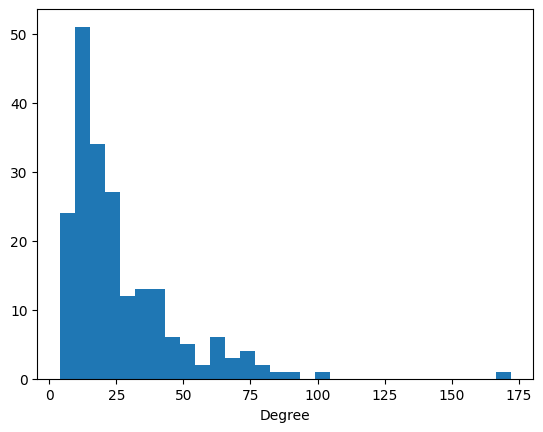

Top degree: 172  p-value: 4.7506397255349e-117
clustering observed 0.371, null 0.359, p = 0.005
DC-SBM groups: 2  entropy: 7277.272894227915
Region: p = 0.000, z = -13.6


In [72]:
## SOLUTION (instructor walkthrough, dataset A)

# Step 0
degs = g_fhu.get_total_degrees(list(g_fhu.vertices()))
print('Clustering:', gt.local_clustering(g_fhu).fa.mean())
print('Approx path length:', gt.pseudo_diameter(g_fhu)[0])
plt.hist(degs, bins=30); plt.xlabel('Degree'); plt.show()   # heavy tail

# Step 1 — top department vs ER
n, m = g_fhu.num_vertices(), g_fhu.num_edges()
p = (2 * m / n) / (n - 1)
k_max = int(degs.max())
print('Top degree:', k_max, ' p-value:',
      binomtest(k_max, n - 1, p, alternative='greater').pvalue)
# astronomically significant -- but that only rejects UNIFORM mixing (rung 1)

# Step 2 — does clustering survive fixing the degrees?
observed = gt.local_clustering(g_fhu).fa.mean()
g_rand = g_fhu.copy()
n_samples = 200
stat_values = np.empty(n_samples)
for i in range(n_samples):
    generation.random_rewire(g_rand, model='configuration')
    stat_values[i] = gt.local_clustering(g_rand).fa.mean()
print(f'clustering observed {observed:.3f}, null {stat_values.mean():.3f}, '
      f'p = {np.mean(stat_values >= observed):.3f}')
# NB: in very dense hub-dominated networks the configuration model itself produces a
# lot of clustering -- the gap here is much smaller than in the school network.
# THIS is the point of rung 2: part of the "special" structure is just degrees.

# Step 3 — DC-SBM preview
state = gt.minimize_blockmodel_dl(g_fhu, state_args={'deg_corr': True})
print('DC-SBM groups:', state.get_B(), ' entropy:', state.entropy())
# block structure beyond degree exists (Wednesday: what do the groups mean, and is
# this fit trustworthy?)

# BESTest on Region
b, mapping = categorical_to_int(g_fhu, 'Region  ')
state = gt.BlockState(g_fhu, b=b)
obs = state.entropy()
null = np.array([random_entropy(g_fhu, np.bincount(b.a)) for _ in range(1000)])
print(f'Region: p = {np.mean(null <= obs):.3f}, '
      f'z = {(obs - null.mean()) / null.std():+.1f}')
# geography IS associated with hiring -- but compare its z-score with what the office
# attribute achieved in the law firm: association can be real yet weak.
#
# Verdict on the naive claim: the hubs are real, but "special" mostly dissolves into
# "has enormous degree" + a prestige hierarchy that rung 3 methods can articulate.


### Dataset B — International food trade

Country-to-country trade from the FAO multiplex dataset
([De Domenico et al., 2015](https://doi.org/10.1038/ncomms7864)): 214 countries, with a
separate layer for each of ~360 products. Pick a product you like and extract its layer.

**The naive claim:** *"Country X sits at the centre of this product's trade — it is a
structurally special broker."* (Pick your own X once you see the degree ranking.)

**Note what's missing:** this dataset has *no categorical node attribute* — so look at your
decision tree: the BESTest branch simply does not apply. Part of using the ladder on your
own data is recognising which rungs your data can support.


In [77]:
g_tr = gt.collection.ns["fao_trade"]
print(g_tr)
print('Node attributes:', list(g_tr.vp.keys()))
print('Edge attributes:', list(g_tr.ep.keys()))
print('Graph attributes:', list(g_tr.gp.keys()))

<Graph object, directed, with 214 vertices and 318346 edges, 3 internal vertex properties, 2 internal edge properties, 6 internal graph properties, at 0x79db63f29f10>
Node attributes: ['name', 'nodeLabel', '_pos']
Edge attributes: ['weight', 'layer']
Graph attributes: ['name', 'description', 'citation', 'url', 'tags', 'layer_key']


In [78]:
# extract one product layer -- check the printed edge-attribute names above for the
# layer property (and adjust the property/value names below if they differ)
layer_prop = g_tr.ep['layer']
layer_id = 1   # pick a product; if a list of layer names exists in g_tr.gp, use it
g_layer = gt.Graph(gt.GraphView(g_tr, efilt=lambda e: layer_prop[e] == layer_id),
                   prune=True)
g_layer.set_directed(False)
gt.remove_parallel_edges(g_layer)
print(g_layer.num_vertices(), 'countries,', g_layer.num_edges(), 'trade links')

214 countries, 3082 trade links


In [ ]:
# Steps 0-3: is your country X more than a big degree?
# insert code here

In [80]:
## SOLUTION (instructor walkthrough, dataset C)

# Identify the "special" country: rank by degree
degs = g_layer.get_total_degrees(list(g_layer.vertices()))
order = np.argsort(degs)[::-1]
names = g_layer.vp['name'] if 'name' in g_layer.vp.keys() else None
for idx in order[:5]:
    print(names[g_layer.vertex(idx)] if names is not None else idx, int(degs[idx]))

# Step 1: its degree is (of course) wildly significant against ER.
n, m = g_layer.num_vertices(), g_layer.num_edges()
p = (2 * m / n) / (n - 1)
k_max = int(degs.max())
print('p-value vs ER:', binomtest(k_max, n - 1, p, alternative='greater').pvalue)

# Step 2: but is the country's BROKERAGE special beyond its degree? Use betweenness
# of the top country as the statistic in the configuration null:
v_top = g_layer.vertex(order[0])
observed = gt.betweenness(g_layer)[0][v_top]
g_rand = g_layer.copy()
stat_values = np.empty(100)          # betweenness is slower -- fewer samples
for i in range(100):
    generation.random_rewire(g_rand, model='configuration')
    stat_values[i] = gt.betweenness(g_rand)[0][g_rand.vertex(order[0])]
print(f'betweenness observed {observed:.4f}, null {stat_values.mean():.4f}, '
      f'p = {np.mean(stat_values >= observed):.3f}')
# Typical outcome: NOT significant, or barely -- once you give the null the same degree
# sequence, "sits in the middle of everything" is largely what a big degree buys you
# for free. The naive claim mostly dissolves at rung 2. THE headline demo of the ladder.

# Step 3 for completeness:
state = gt.minimize_blockmodel_dl(g_layer, state_args={'deg_corr': True})
print('DC-SBM groups:', state.get_B())
# and note explicitly with students: no categorical attribute -> no BESTest branch.

United_States_of_America 130
France 123
Netherlands 119
Germany 117
Austria 117
p-value vs ER: 2.778411208848658e-58
betweenness observed 0.0567, null 0.0516, p = 0.280
DC-SBM groups: 8


### Now try your own data



In the last part of this morning you can switch to **your own network data**.

1. Upload your edge-list CSV to a folder in your Google Drive (see `BRING_YOUR_OWN_DATA.md`
   for the format).
2. Run the cell below and authorize access.
3. Edit `my_data_path` to point at your file and check that it prints **File found**.

No data of your own (yet)? Run the cell anyway to test the Drive mount, then move on.


In [ ]:
from google.colab import drive
drive.mount('/drive')

import os
# --- edit this path to point at your own file ---
my_data_path = '/drive/MyDrive/network_summer_school/my_edgelist.csv'

if os.path.exists(my_data_path):
    print('File found — you are ready for the own-data practical.')
else:
    print('File NOT found at', my_data_path)
    print('Check the folder name and file name (case-sensitive), or ask an instructor now.')

# Alternative if you prefer not to mount Drive: uncomment the two lines below to
# upload a file directly into the Colab session instead (it disappears when the
# session ends, so you would need to re-upload tomorrow).
# from google.colab import files
# uploaded = files.upload()

Mounted at /drive
File NOT found at /drive/MyDrive/network_summer_school/my_edgelist.csv
Check the folder name and file name (case-sensitive), or ask an instructor now.


## 8 — Where this goes next

**Today's argument in one line:** a network property is only meaningful relative to a null
model, and the ladder (ER → configuration → DC-SBM, with the BESTest for attributes) tells
you which "boring" explanation you've ruled out so far.

**Wednesday** starts exactly where rung 3 left off: *my network looks like it has groups —
is that real, and what are they?* Same null-test recipe, same BESTest, new question.
